In [26]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')


## Data preparing and cleaning 

In [27]:
df = pd.read_csv('../data/kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [28]:
print(df.size)
print(df.shape)

10400
(400, 26)


In [29]:
df['classification'] = df['classification'].str.strip()
df['classification'] = df['classification'].map({'ckd': 1, 'notckd': 0})

print(df['classification'].dtype)
print(df['classification'].unique())

int64
[1 0]


In [30]:
df['classification'].value_counts()

classification
1    250
0    150
Name: count, dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [32]:
for col in df.columns:
    print(f"{col} contains {df[col].isnull().sum()} null values")

id contains 0 null values
age contains 9 null values
bp contains 12 null values
sg contains 47 null values
al contains 46 null values
su contains 49 null values
rbc contains 152 null values
pc contains 65 null values
pcc contains 4 null values
ba contains 4 null values
bgr contains 44 null values
bu contains 19 null values
sc contains 17 null values
sod contains 87 null values
pot contains 88 null values
hemo contains 52 null values
pcv contains 70 null values
wc contains 105 null values
rc contains 130 null values
htn contains 2 null values
dm contains 2 null values
cad contains 2 null values
appet contains 1 null values
pe contains 1 null values
ane contains 1 null values
classification contains 0 null values


In [33]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,classification
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,400.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,0.625000
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,0.484729
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,0.000000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,0.000000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,1.000000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,1.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,1.000000


In [34]:
for col in df.select_dtypes(include="number").columns:
    df[col].fillna(df[col].median(),inplace=True)

In [35]:
for col in df.columns:
    print(f"{col} contains {df[col].isnull().sum()} null values")

id contains 0 null values
age contains 0 null values
bp contains 0 null values
sg contains 0 null values
al contains 0 null values
su contains 0 null values
rbc contains 152 null values
pc contains 65 null values
pcc contains 4 null values
ba contains 4 null values
bgr contains 0 null values
bu contains 0 null values
sc contains 0 null values
sod contains 0 null values
pot contains 0 null values
hemo contains 0 null values
pcv contains 70 null values
wc contains 105 null values
rc contains 130 null values
htn contains 2 null values
dm contains 2 null values
cad contains 2 null values
appet contains 1 null values
pe contains 1 null values
ane contains 1 null values
classification contains 0 null values


In [36]:
for col in df.select_dtypes(include= 'object').columns:
    df[col].fillna(df[col].mode()[0],inplace = True)

In [37]:
df.select_dtypes(include='object').isnull().sum()

rbc      0
pc       0
pcc      0
ba       0
pcv      0
wc       0
rc       0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
dtype: int64

In [38]:
df.isna().sum().sum()

np.int64(0)

In [39]:
df = df.drop(columns= 'id')

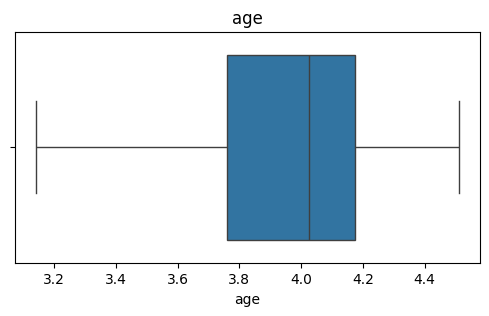

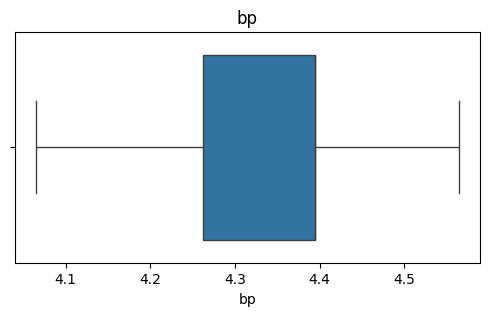

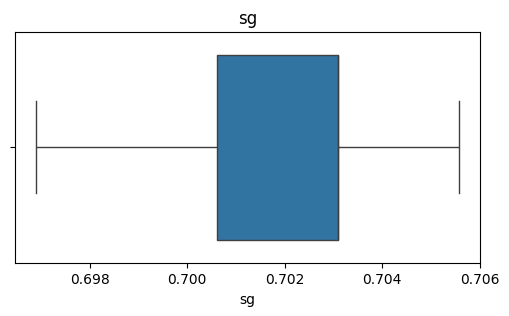

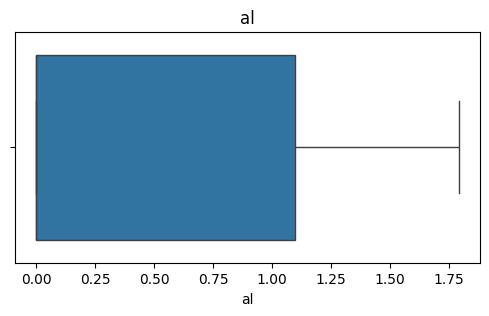

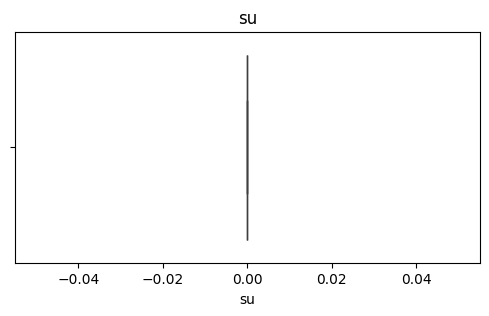

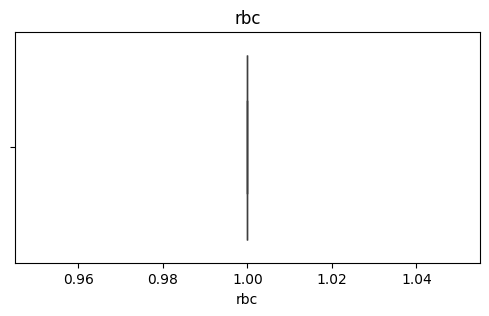

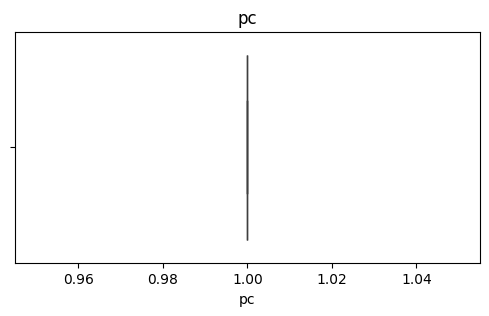

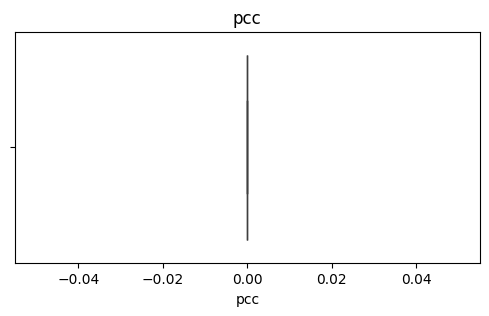

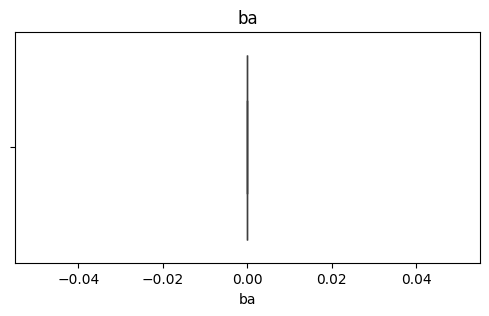

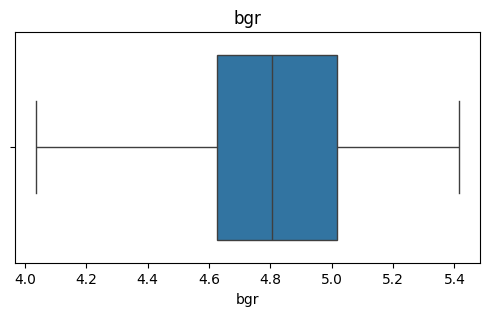

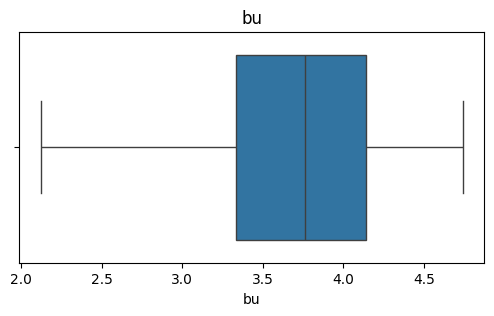

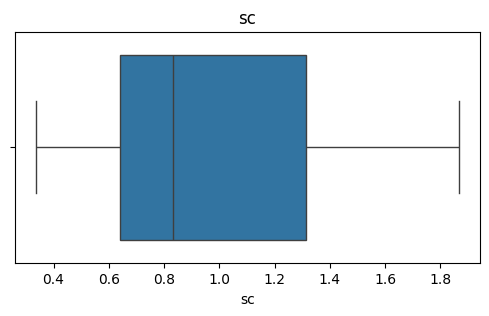

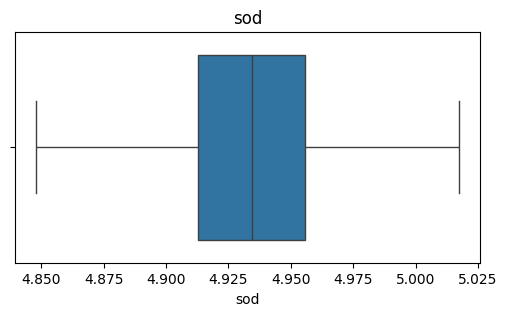

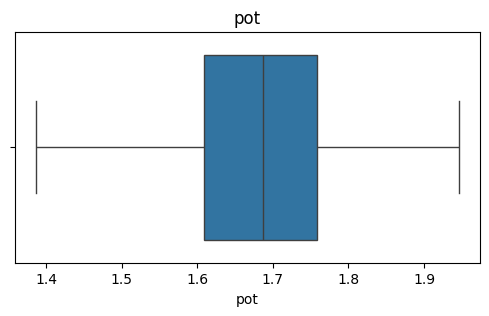

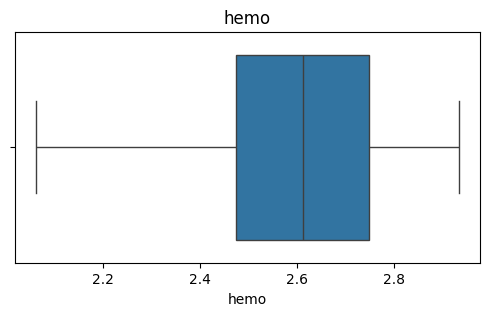

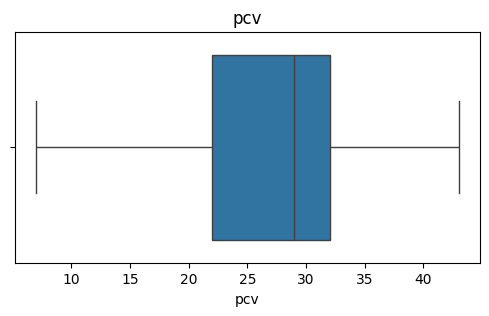

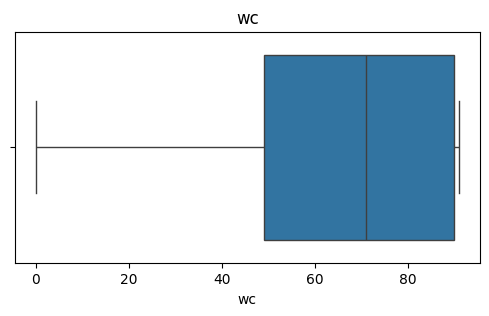

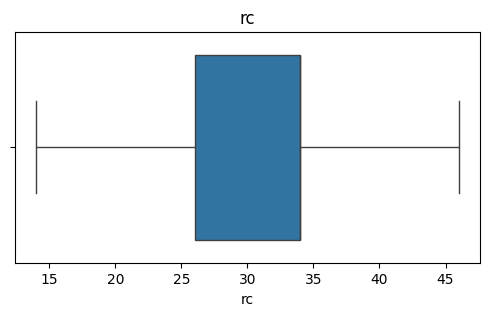

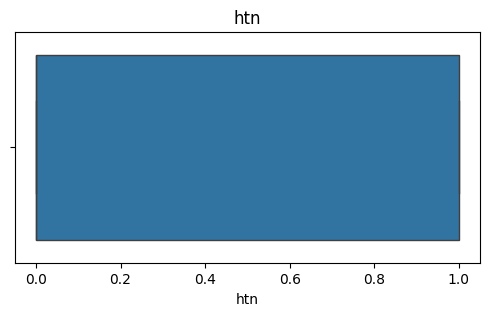

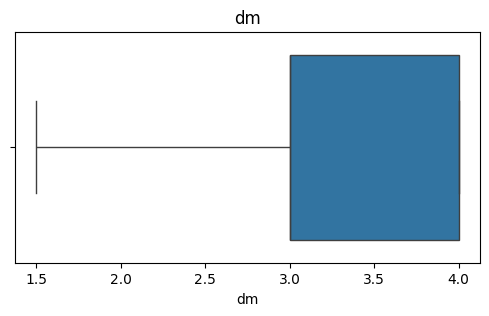

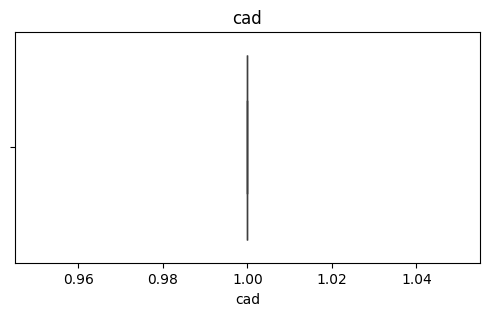

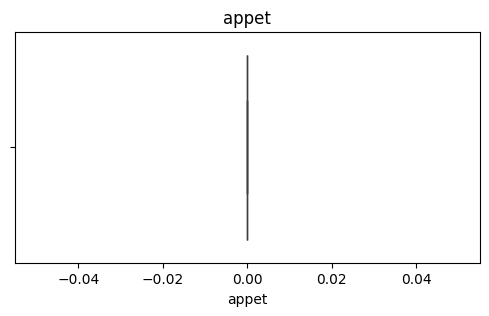

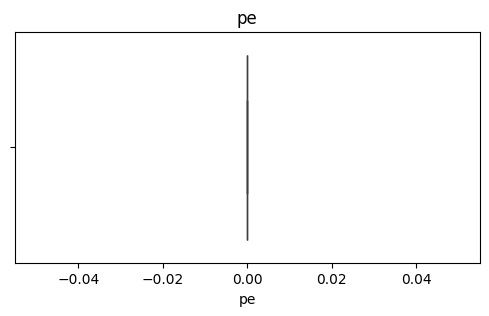

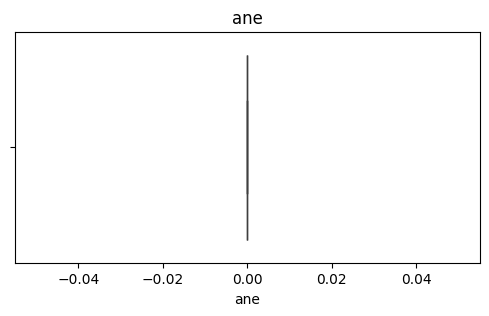

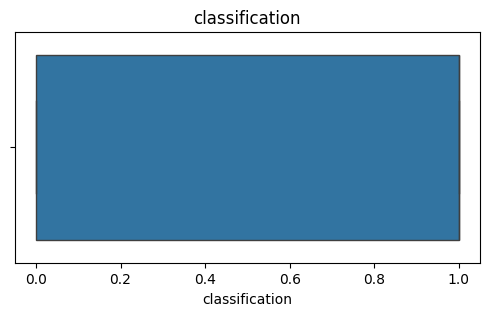

In [81]:
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [80]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

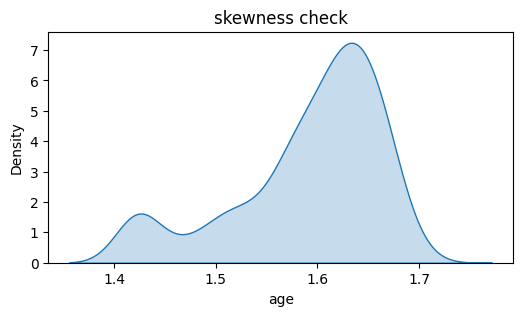

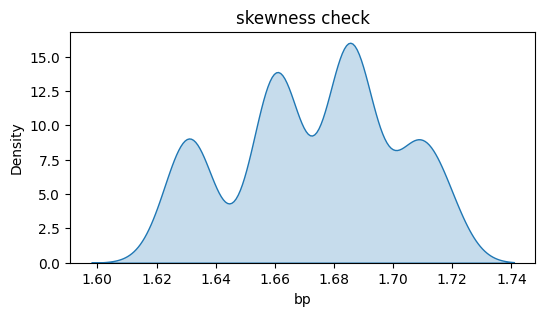

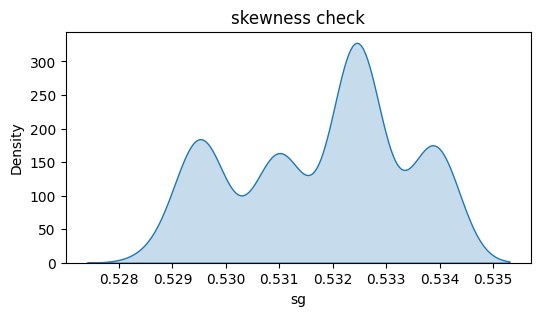

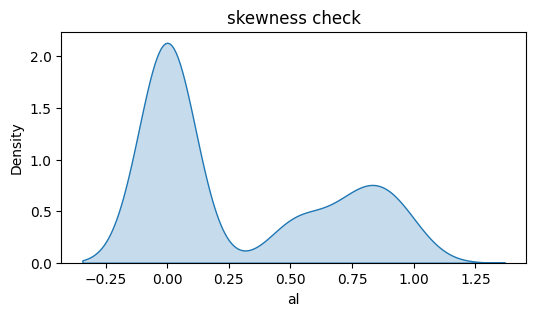

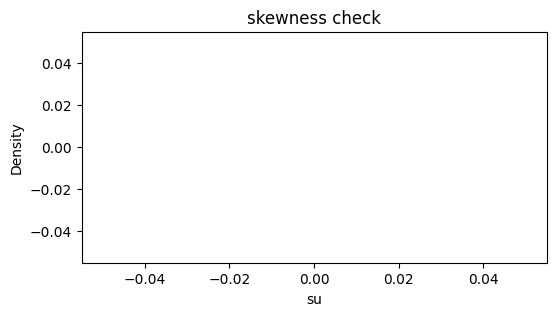

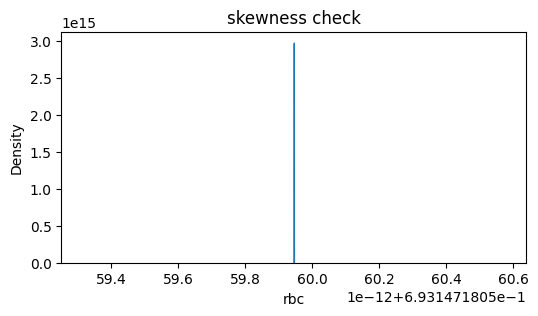

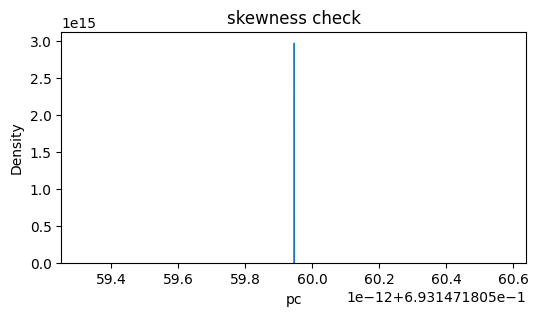

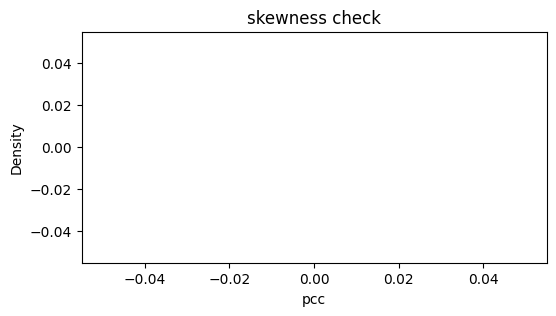

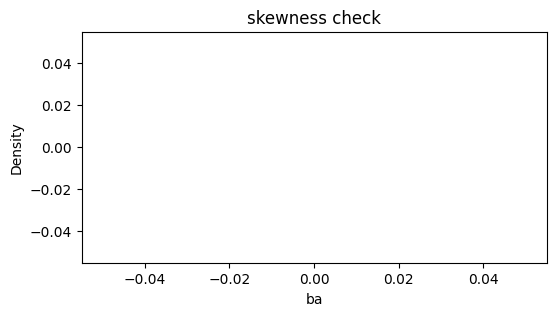

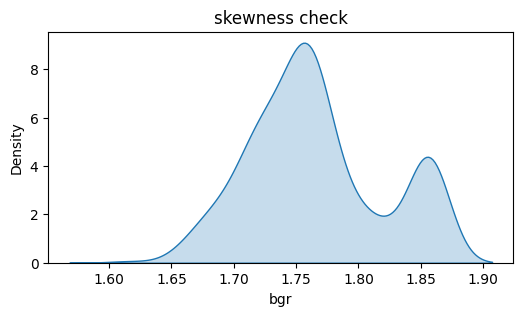

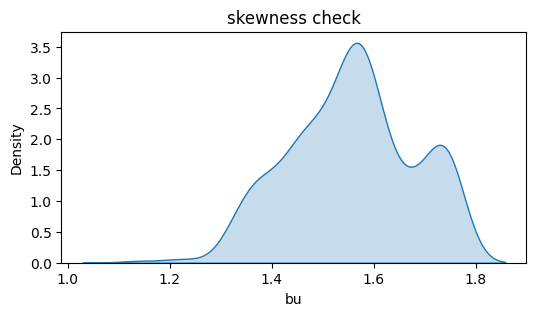

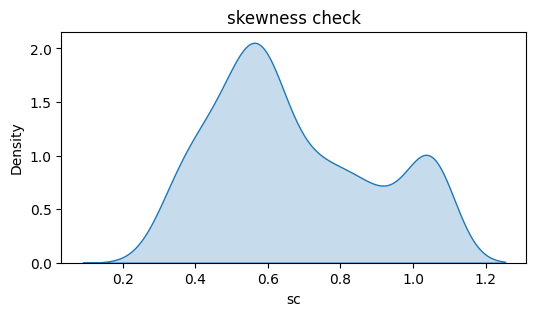

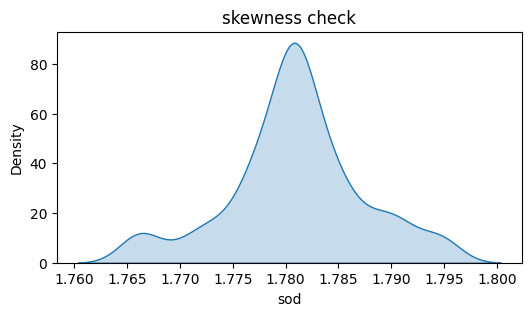

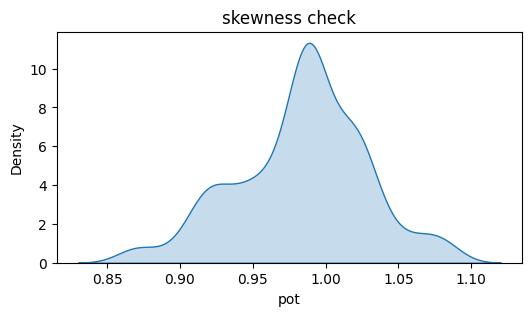

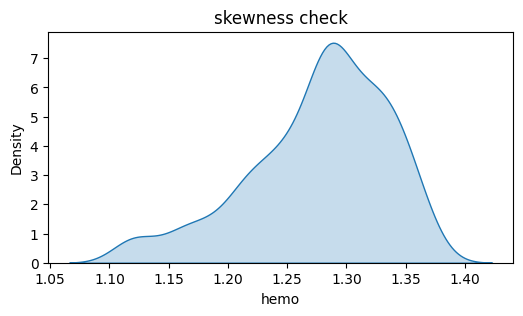

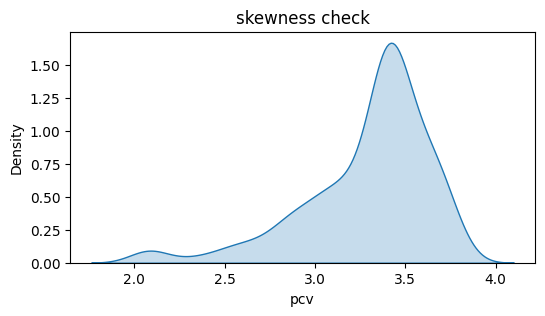

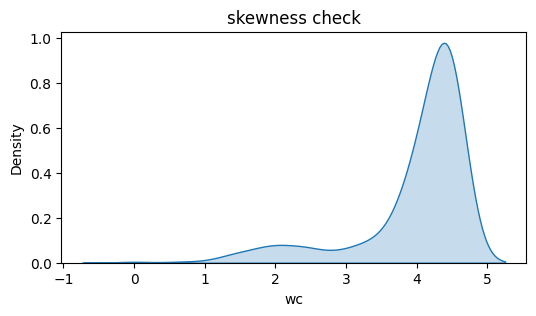

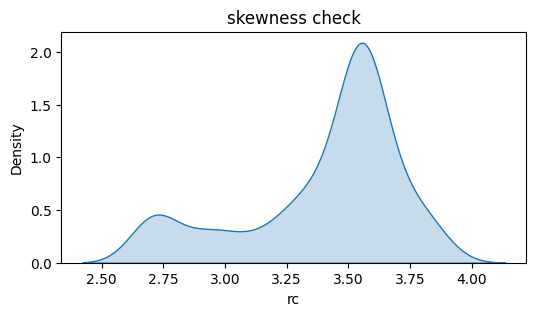

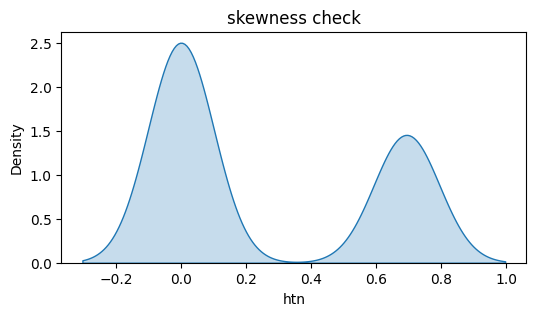

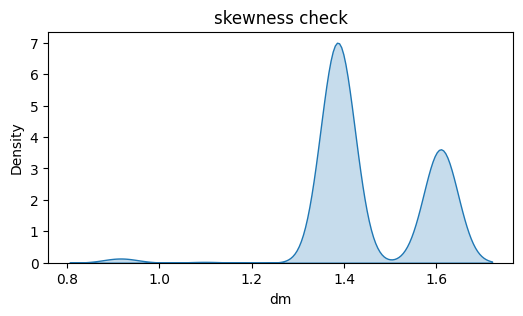

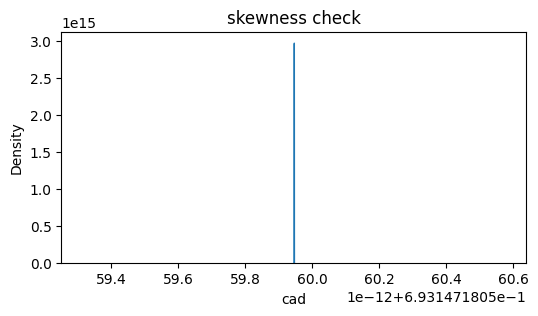

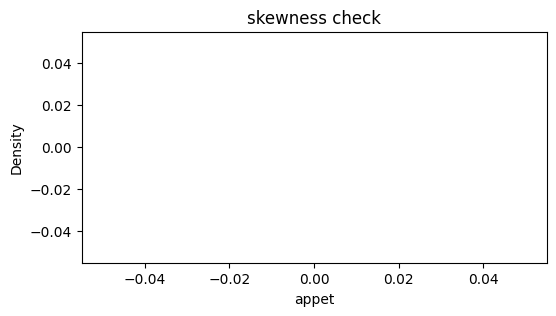

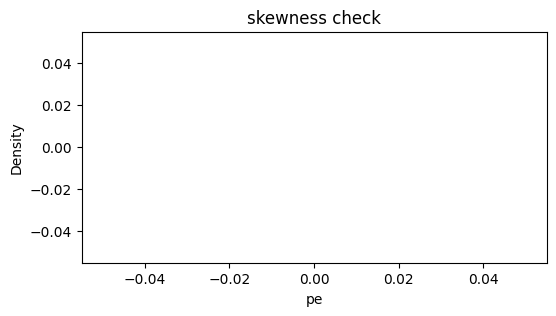

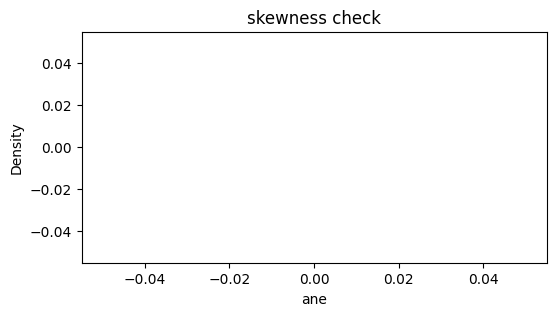

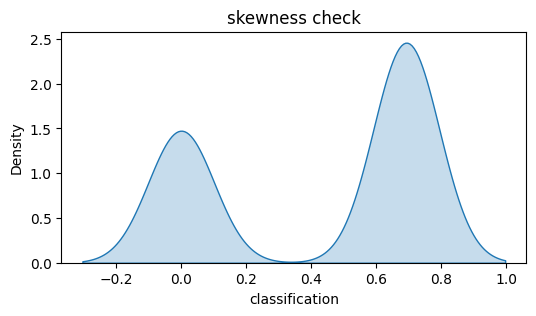

In [84]:
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    plt.figure(figsize = (6,3))
    plt.title('skewness check')
    sns.kdeplot(df[col],fill=True)
    plt.xlabel(col)
    plt.show()

In [83]:
df.select_dtypes(include='number').skew().sort_values(ascending=False)

al                0.658068
htn               0.551722
sc                0.445893
bgr               0.349441
ba                0.000000
appet             0.000000
pe                0.000000
ane               0.000000
cad               0.000000
pcc               0.000000
pc                0.000000
rbc               0.000000
su                0.000000
sod              -0.150393
bu               -0.169109
bp               -0.184654
sg               -0.266014
pot              -0.276389
classification   -0.518344
dm               -0.556914
hemo             -0.782180
rc               -1.030996
age              -1.055774
pcv              -1.408548
wc               -2.083575
dtype: float64

In [82]:
for col in num_cols:
    df[col] = np.log1p(df[col])


In [45]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


df.dtypes

age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                 int64
pc                  int64
pcc                 int64
ba                  int64
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                 int64
wc                  int64
rc                  int64
htn                 int64
dm                  int64
cad                 int64
appet               int64
pe                  int64
ane                 int64
classification    float64
dtype: object

## Model Training and Testing 

In [46]:
from sklearn.preprocessing import StandardScaler 
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , RandomizedSearchCV 
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score , confusion_matrix

In [54]:
df['classification'] = (df['classification'] > 0).astype(int)

In [ ]:
X=df.drop(columns ='classification')
y = df['classification']


0      1
1      1
2      1
3      1
4      1
      ..
395    0
396    0
397    0
398    0
399    0
Name: classification, Length: 400, dtype: int64

In [56]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=11)



In [57]:
lr_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',LogisticRegression(max_iter= 1000))
])
lr_pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [61]:
y_pred_lr = lr_pipeline.predict(X_test)
print(accuracy_score(y_test,y_pred_lr))

print(confusion_matrix(y_test,y_pred_lr))

0.9875
[[29  1]
 [ 0 50]]


In [67]:
rf_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',RandomForestClassifier(random_state=12,criterion='gini', max_depth =20))
])

rf_pipeline.fit(X_train,y_train)


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,20
,min_samples_split,2


In [69]:
y_pred_rf = rf_pipeline.predict(X_test)
print(accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))

0.9625
[[27  3]
 [ 0 50]]


In [70]:
ada_pipieline = Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',AdaBoostClassifier(estimator=LogisticRegression(),learning_rate=0.01))
])
ada_pipieline.fit(X_train,y_train)



,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,LogisticRegression()
,n_estimators,50
,learning_rate,0.01
,algorithm,'deprecated'


In [74]:
y_pred_ada = ada_pipieline.predict(X_test)
print(accuracy_score(y_test ,y_pred_ada))
print(confusion_matrix(y_test,y_pred_ada))

0.9875
[[29  1]
 [ 0 50]]


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr_pipeline, X, y, cv=5)

print(scores)
print("Mean Accuracy:", scores.mean())



[1.     0.9875 0.975  0.9875 1.    ]
Mean Accuracy: 0.99


In [76]:
from sklearn.model_selection import cross_val_score

scores_02 = cross_val_score(rf_pipeline, X, y, cv=5)

print(scores)
print("Mean Accuracy:", scores.mean())

[1.     0.9875 0.975  0.9875 1.    ]
Mean Accuracy: 0.99


In [77]:
import joblib 
joblib.dump(lr_pipeline,'kidney_predictions.pkl')

print("saved")

saved
